<a href="https://colab.research.google.com/github/sabithakrishnan/multimodal-image-analysis/blob/main/multimodalimage_recognition_nceloss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open-clip-torch datasets pillow torch torchvision matplotlib


In [ ]:

import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

class ProductionDatasetBuilder:
    def __init__(self, dataset_repo: str = "blanchon/EuroSAT_RGB"):
        self.repo = dataset_repo

    def build_local_directory(self, output_dir: str = "satellite_dataset"):
        dest_path = Path(output_dir)

        # Guard clause: avoid re-running if data exists
        if dest_path.exists() and any(dest_path.iterdir()):
            print(f"📦 Workspace directory '{output_dir}' already exists. Transitioning steps...")
            return

        print(f"📡 Accessing Hugging Face native parquet tables for '{self.repo}'...")
        # Loads clean tabular shards; completely bypasses legacy python execution scripts
        dataset_split = load_dataset(self.repo, split="train")

        # Dynamically infer the land-use taxonomy from the Metadata Table schema
        label_names = dataset_split.features["label"].names
        print(f"🎯 Verified {len(label_names)} target categories for extraction.")

        print("\n💾 Unpacking and storing satellite tensors to local filesystems...")
        for idx, sample in enumerate(tqdm(dataset_split, desc="Processing Satellite Tiles")):
            pil_img = sample["image"]
            label_id = sample["label"]

            # Sanitize naming structures to eliminate runtime mapping mistakes
            class_name = label_names[label_id].replace(" ", "")

            # Map path structure: satellite_dataset/IndustrialBuildings/tile_x.jpg
            class_folder = dest_path / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            file_name = class_folder / f"tile_{idx}.jpg"

            if pil_img.mode != "RGB":
                pil_img = pil_img.convert("RGB")

            pil_img.save(file_name, "JPEG")

        print(f"\n✅ Step 2 Complete! File mapping successfully resolved inside: '{dest_path.resolve()}'")

if __name__ == "__main__":
    builder = ProductionDatasetBuilder()
    builder.build_local_directory()


📦 Workspace directory 'satellite_dataset' already exists. Transitioning steps...


/tmp/ipykernel_1441/910482130.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(



--- Training Starting ---


Epoch 1/5:   0%|          | 0/203 [00:00<?, ?it/s]/tmp/ipykernel_1441/910482130.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 1/5: 100%|██████████| 203/203 [01:39<00:00,  2.04it/s]


Epoch 1 Loss: 2.9832


Epoch 2/5: 100%|██████████| 203/203 [01:40<00:00,  2.01it/s]


...

Epoch 4 Loss: 2.3236


Epoch 5/5: 100%|██████████| 203/203 [01:40<00:00,  2.03it/s]


Epoch 5 Loss: 2.2132

--- Testing & Evaluation Starting ---


Evaluating: 100%|██████████| 51/51 [00:11<00:00,  4.58it/s]


Accuracy: 0.8157
Precision: 0.8048
Recall:    0.8102
F1-Score:  0.8051


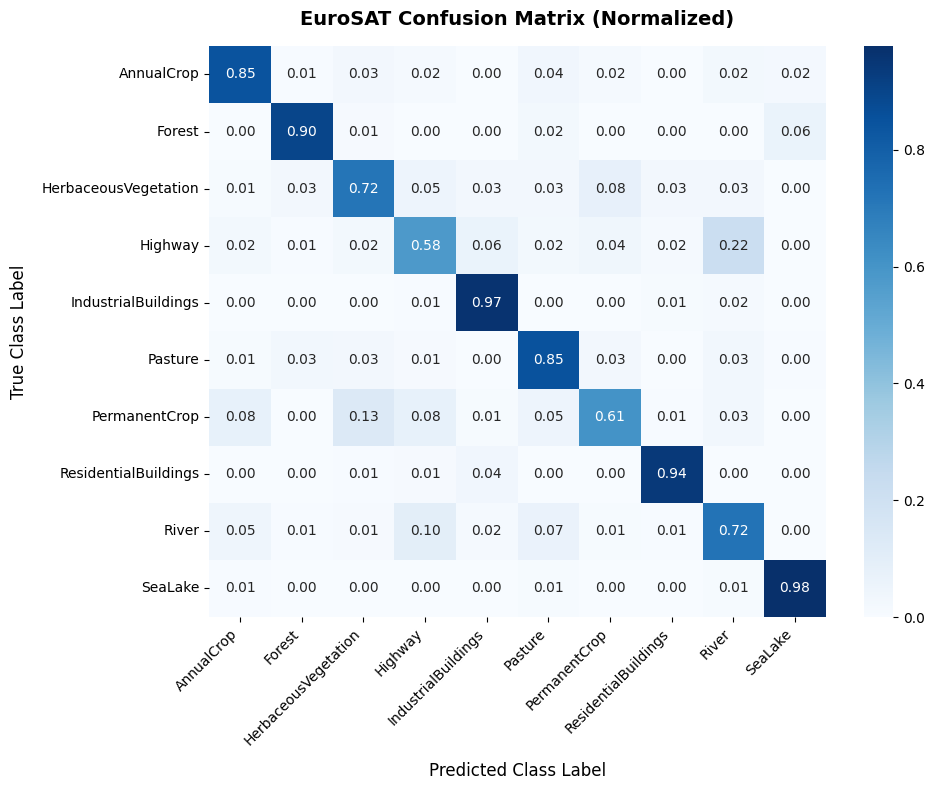

/tmp/ipykernel_1441/910482130.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, palette="viridis")


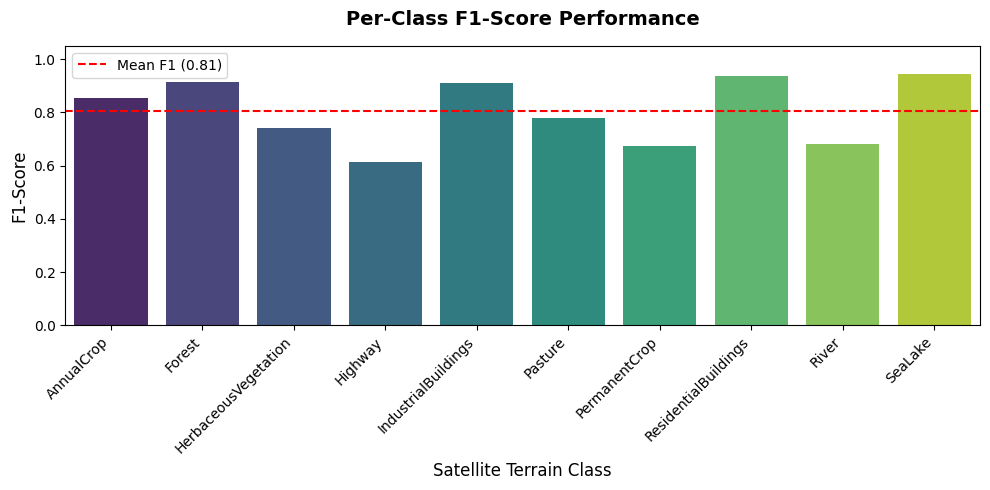

💾 F1-Score chart saved as 'per_class_f1_scores.png'


<Figure size 1000x500 with 0 Axes>

In [ ]:
import os
import zipfile
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Setting hyperparameters
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
LATENT_DIM = 128
NUM_CLASSES = 10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#loading dataset and extracting the classes
full_dataset = datasets.ImageFolder(root="satellite_dataset", transform=transform)
classes = full_dataset.classes  # Saved into the required variable 'classes'
#Splitting the dataset into testing and training
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
#Using dataloader for efficient model loading
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
#Defing multimodal model using neural network and nce loss
class MultimodalModel(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(MultimodalModel, self).__init__()
     # building image processing network
        self.image_tower = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, latent_dim)
        )
       #building text processing network
        self.text_tower = nn.Sequential(
            nn.Linear(num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        self.temperature = nn.Parameter(torch.ones([]) * 0.07)

    def forward_image(self, x):
        return F.normalize(self.image_tower(x), p=2, dim=-1)

    def forward_text(self, x):
        return F.normalize(self.text_tower(x), p=2, dim=-1)

model = MultimodalModel(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)
scaler = GradScaler()

# INFO-NCE LOSS FUNCTION
def info_nce_loss(image_embeddings, text_embeddings, temp):
    logits = torch.matmul(image_embeddings, text_embeddings.T) / temp
    targets = torch.arange(image_embeddings.size(0), device=image_embeddings.device)
    loss_img = F.cross_entropy(logits, targets)
    loss_txt = F.cross_entropy(logits.T, targets)
    return (loss_img + loss_txt) / 2

#Model training
print("\n--- Training Starting ---")
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for raw_images, label_ids in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = raw_images.to(device)
        one_hot_labels = F.one_hot(label_ids, num_classes=NUM_CLASSES).float().to(device)

        optimizer.zero_grad()
        with autocast():
            image_latents = model.forward_image(images)
            text_latents = model.forward_text(one_hot_labels)
            loss = info_nce_loss(image_latents, text_latents, model.temperature)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_train_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1} Loss: {total_train_loss/len(train_loader):.4f}")

# ==========================================
# 7. EVALUATION LOOP (STRUCTURALLY IDENTICAL TO TRAINING)
# ==========================================
print("\n--- Testing & Evaluation Starting ---")
model.eval()

# Build the reference vector for ALL 10 classes once
with torch.no_grad():
    all_possible_classes_one_hot = torch.eye(NUM_CLASSES).float().to(device)
    class_text_embeddings = model.forward_text(all_possible_classes_one_hot)

all_targets = []
all_predictions = []
all_confidences = []
all_correctness = []

with torch.no_grad():
    for raw_images, label_ids in tqdm(test_loader, desc="Evaluating"):
        images = raw_images.to(device)
        image_latent_embeddings = model.forward_image(images)
        similarity_scores = torch.matmul(image_latent_embeddings, class_text_embeddings.T)
        #Get raw prediction index
        predictions = torch.argmax(similarity_scores, dim=-1)

        # Get raw confidence metrics (the highest similarity value)
        confidences = torch.max(similarity_scores, dim=-1)[0]

        # Append data directly to visualization lists
        all_targets.extend(label_ids.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

        correct_batch = (predictions.cpu() == label_ids).numpy()
        all_correctness.extend(correct_batch)

# Convert all variables explicitly into NumPy formats for your plots
all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)
all_confidences = np.array(all_confidences)
all_correctness = np.array(all_correctness)


# Compute and normalize the matrix using your exact logic block
cm = sk_confusion_matrix(all_targets, all_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Compute classification report and extract per class F1 score
report_dict = classification_report(all_targets, all_predictions, target_names=classes, output_dict=True)
f1_scores = [report_dict[cls]['f1-score'] for cls in classes]

# Detailed metrics for global macro-averaging
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP

# Adding a small epsilon (1e-7) prevents "division by zero" errors
class_precision = TP / (TP + FP + 1e-7)
class_recall    = TP / (TP + FN + 1e-7) # Equivalent to Sensitivity
class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-7)

# --- Global Macro-Averaging ---
total_correct = np.sum(all_correctness)
total_samples = len(all_targets)
accuracy = total_correct / total_samples

precision = np.mean(class_precision)
recall    = np.mean(class_recall)
f1        = np.mean(class_f1)

print(f"Accuracy: {accuracy:.4f}") # Overall match
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Create the heatmap plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True
)

plt.title("EuroSAT Confusion Matrix (Normalized)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Class Label", fontsize=12, labelpad=10)
plt.ylabel("True Class Label", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot F1-Scores
plt.figure(figsize=(10, 5))
sns.barplot(x=classes, y=f1_scores, palette="viridis")
plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean F1 ({np.mean(f1_scores):.2f})')
plt.title("Per-Class F1-Score Performance", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Satellite Terrain Class", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1_scores.png') # Ensures it explicitly writes to folder path
plt.show()
print("💾 F1-Score chart saved as 'per_class_f1_scores.png'")

# Plot Confidence Distribution broken down by True vs False predictions
plt.figure(figsize=(10, 5))
df_perf = {"Confidence": all_confidences, "Correct": all_correctness}
